# Crop Recommendation - EDA and Model Training

**Features:** N, P, K, temperature, humidity, ph, rainfall  
**Target:** crop label (20 classes)  
**Pipeline:** EDA -> clean -> scale -> train multiple models -> compare -> save best

## 1. Imports and Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# paths
ROOT       = Path('.')
DATA_PATH  = ROOT / 'dataset' / 'crop_recommendation.csv'
MODELS_DIR = ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
FEATURES     = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

sns.set_theme(style='whitegrid', palette='muted')
print('Setup complete')

Setup complete


## 2. Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (5050, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,41.9,44.6,47.6,17.57,66.89,6.91,61.39,Barley
1,94.9,69.0,75.6,21.29,70.25,6.54,83.82,Maize
2,94.7,59.3,53.1,26.12,84.51,6.74,225.88,Rice
3,59.8,64.0,58.2,18.44,70.99,6.41,53.55,Onion
4,56.4,32.8,23.6,28.88,46.79,6.56,48.26,Millet


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            5032 non-null   float64
 1   P            5034 non-null   float64
 2   K            5036 non-null   float64
 3   temperature  5038 non-null   float64
 4   humidity     5032 non-null   float64
 5   ph           5037 non-null   float64
 6   rainfall     5041 non-null   float64
 7   label        5050 non-null   object 
dtypes: float64(7), object(1)
memory usage: 315.8+ KB


In [4]:
df.describe().round(2)

,N,P,K,temperature,humidity,ph,rainfall
count,5032.00,5034.00,5036.00,5038.00,5032.00,5037.00,5041.00
mean,69.42,58.96,77.87,22.11,71.19,6.40,83.99
std,33.18,22.44,79.74,5.56,10.96,0.60,56.75
min,-9.90,-9.98,-5.10,-4.80,7.51,1.21,0.28
25%,39.18,46.40,33.30,17.74,63.88,6.18,52.86
50%,64.10,59.80,60.30,21.31,70.01,6.43,66.36
75%,94.00,72.70,79.82,26.84,80.97,6.68,97.11
max,297.17,273.51,549.30,59.26,119.19,13.87,789.57


## 3. Exploratory Data Analysis

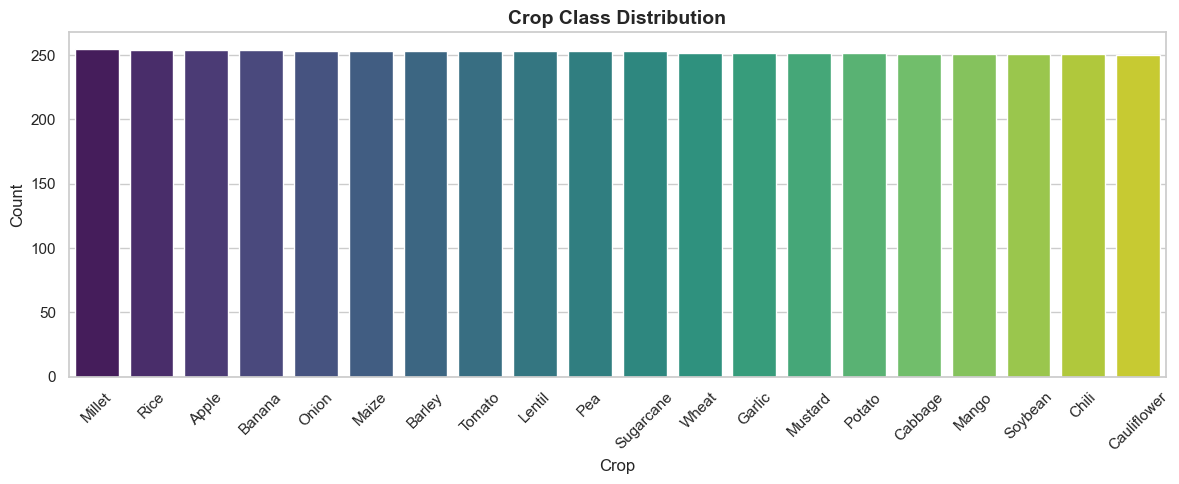

In [5]:
# class distribution
fig, ax = plt.subplots(figsize=(12, 5))
counts = df['label'].value_counts()
sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='viridis')
ax.set_title('Crop Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Crop')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [6]:
# missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0])
print(f'\nTotal missing: {missing.sum()} / {df.size} ({missing.sum()/df.size*100:.2f}%)')

Missing values per column:
N              18
P              16
K              14
temperature    12
humidity       18
ph             13
rainfall        9
dtype: int64

Total missing: 100 / 40400 (0.25%)


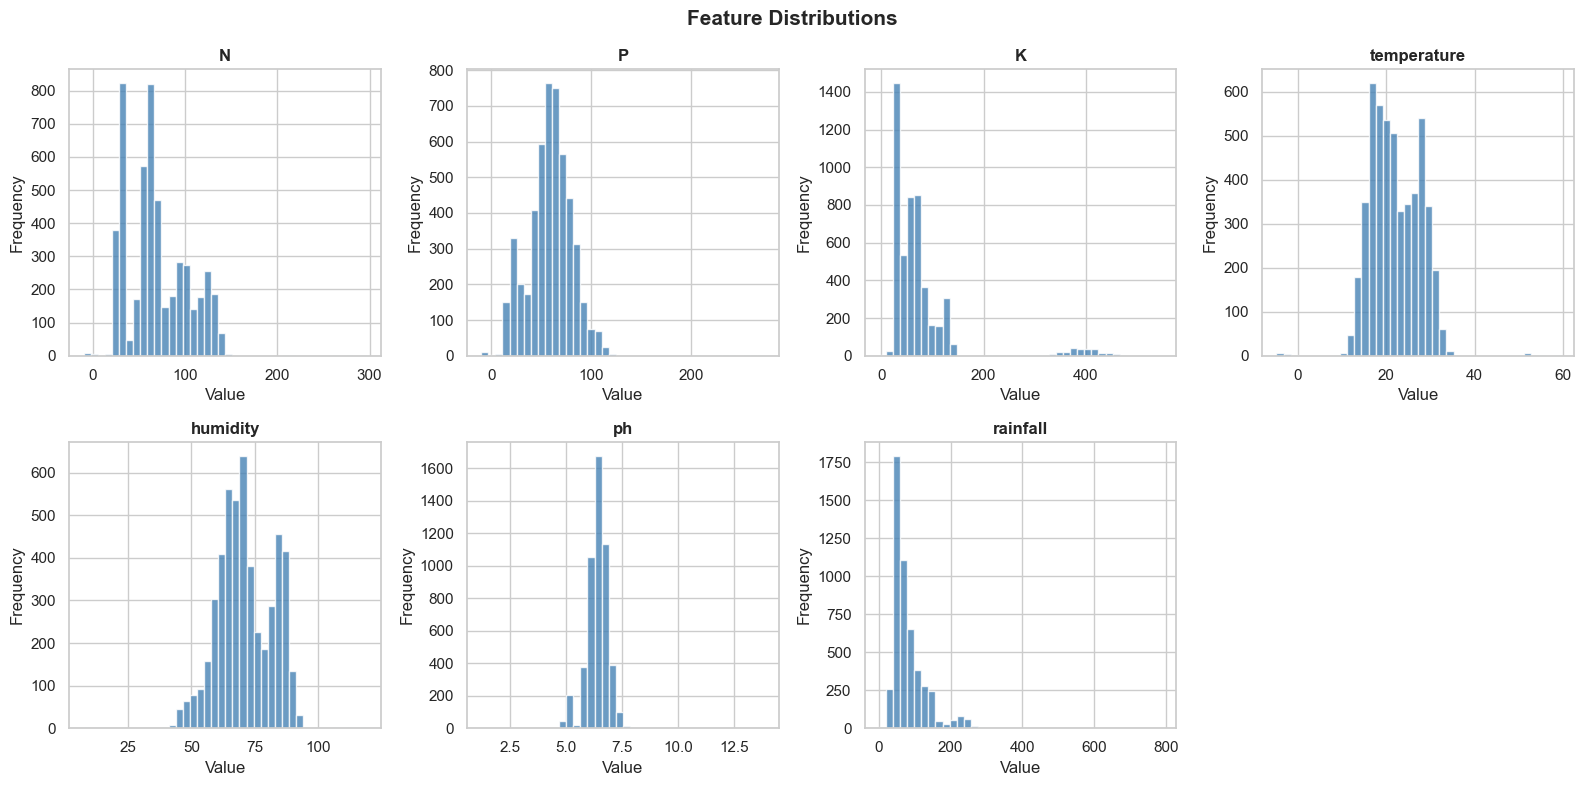

In [8]:
# feature distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(FEATURES):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
axes[-1].set_visible(False)
fig.suptitle('Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

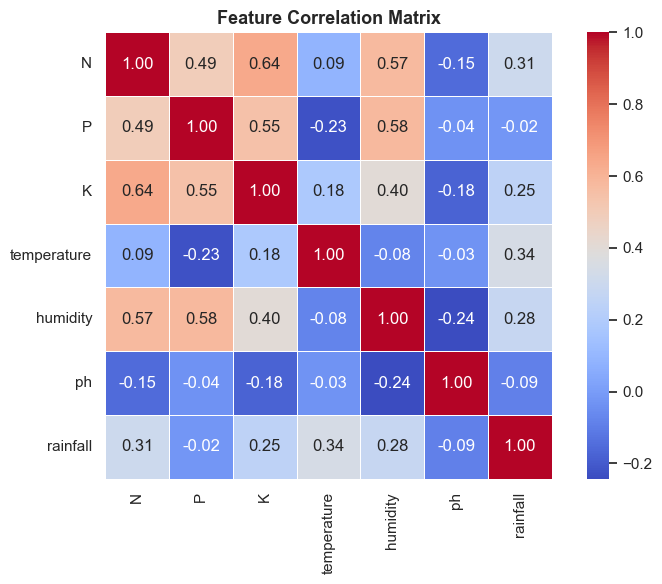

In [9]:
# correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[FEATURES].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

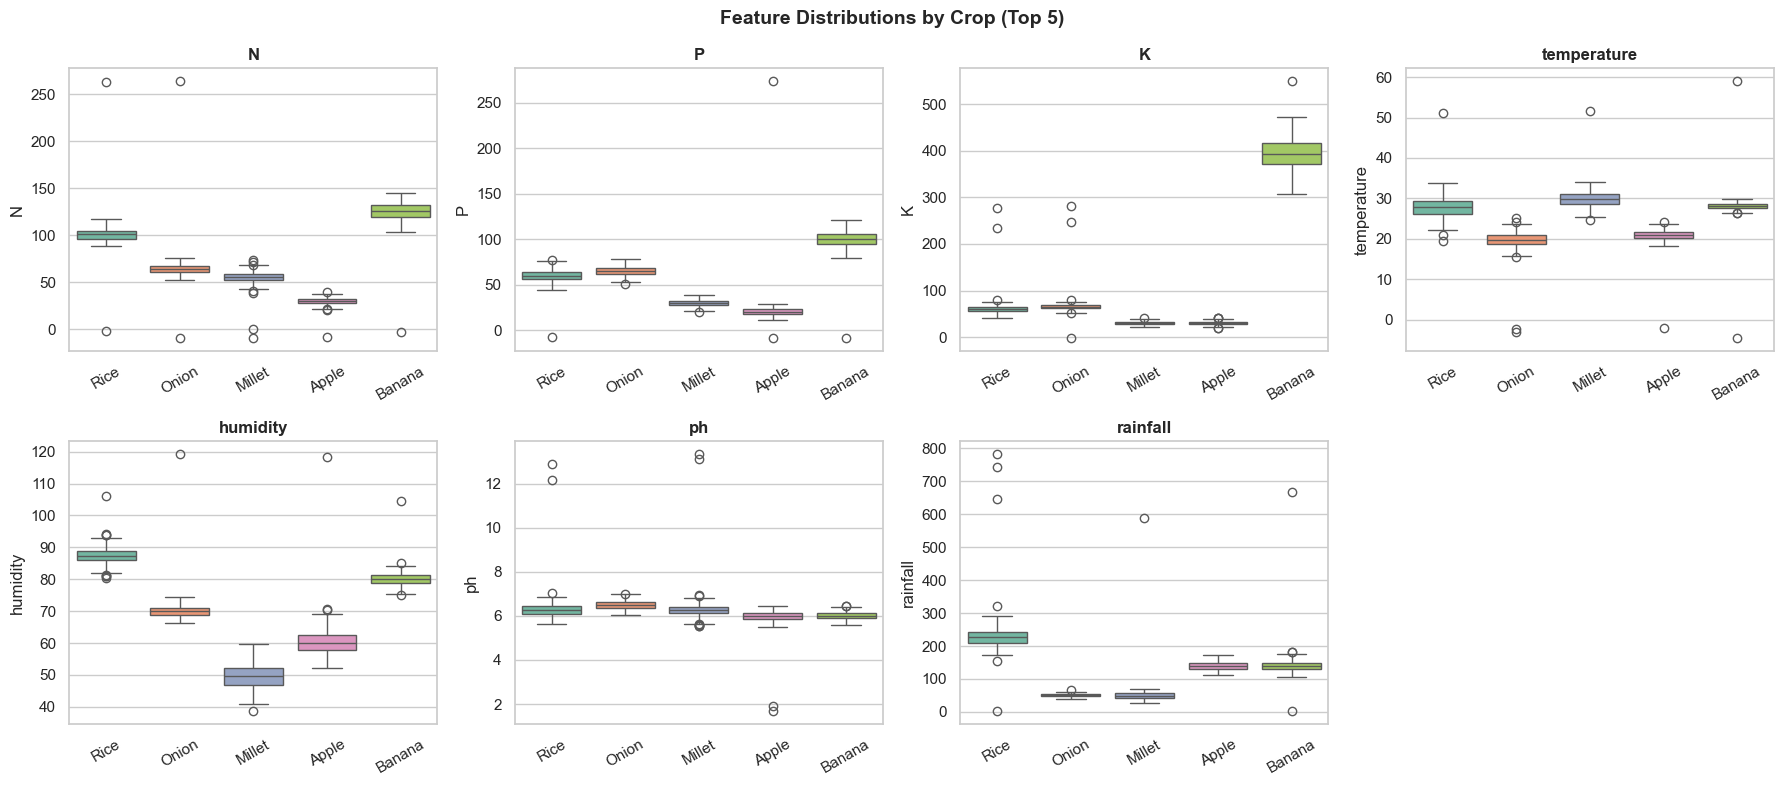

In [10]:
# boxplots: feature vs top-5 crops
top5 = df['label'].value_counts().head(5).index.tolist()
df5  = df[df['label'].isin(top5)]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(FEATURES):
    sns.boxplot(data=df5, x='label', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
axes[-1].set_visible(False)
fig.suptitle('Feature Distributions by Crop (Top 5)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [11]:
# 4.1 drop rows with any missing value
df_clean = df.dropna().copy()
print(f'Rows after dropping NaN: {len(df_clean)} (removed {len(df) - len(df_clean)})')

Rows after dropping NaN: 4950 (removed 100)


In [12]:
# 4.2 clip extreme outliers (1st-99th percentile per feature)
for col in FEATURES:
    q1, q3 = df_clean[col].quantile([0.01, 0.99])
    df_clean[col] = df_clean[col].clip(lower=q1, upper=q3)

print('Outlier clipping done')
df_clean.describe().round(2)

Outlier clipping done


,N,P,K,temperature,humidity,ph,rainfall
count,4950.00,4950.00,4950.00,4950.00,4950.00,4950.00,4950.00
mean,69.20,58.71,77.56,22.11,71.16,6.39,82.54
std,32.20,20.98,78.67,5.21,10.63,0.46,45.82
min,23.90,15.50,23.60,12.46,46.32,5.00,32.32
25%,38.92,46.30,33.30,17.75,63.87,6.18,52.86
50%,64.10,59.80,60.25,21.33,69.97,6.44,66.19
75%,93.80,72.60,79.47,26.85,80.94,6.68,97.10
max,138.40,107.80,422.35,32.71,91.05,7.39,253.90


In [13]:
# 4.3 encode labels
le = LabelEncoder()
df_clean['label_enc'] = le.fit_transform(df_clean['label'])

print('Classes:', le.classes_.tolist())
print('Encoded sample:')
print(df_clean[['label', 'label_enc']].head(3))

Classes: ['Apple', 'Banana', 'Barley', 'Cabbage', 'Cauliflower', 'Chili', 'Garlic', 'Lentil', 'Maize', 'Mango', 'Millet', 'Mustard', 'Onion', 'Pea', 'Potato', 'Rice', 'Soybean', 'Sugarcane', 'Tomato', 'Wheat']
Encoded sample:
    label  label_enc
0  Barley          2
1   Maize          8
2    Rice         15


In [14]:
# 4.4 train / test split
X = df_clean[FEATURES].values
y = df_clean['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (3960, 7)  |  Test: (990, 7)


In [15]:
# 4.5 scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Scaling done')

Scaling done


## 5. Model Training

In [16]:
# define all models
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.1, max_depth=5, random_state=RANDOM_STATE
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=7, metric='euclidean', n_jobs=-1
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

print('Models defined:')
for name in models:
    print(f'  - {name}')

Models defined:
  - Random Forest
  - Gradient Boosting
  - KNN
  - Logistic Regression


In [17]:
# train all models and collect results
results = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_sc, y_train)

    y_pred   = model.predict(X_test_sc)
    test_acc = accuracy_score(y_test, y_pred)

    cv_scores = cross_val_score(model, X_train_sc, y_train, cv=5,
                                scoring='accuracy', n_jobs=-1)

    results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'test_acc': test_acc,
        'cv_mean':  cv_scores.mean(),
        'cv_std':   cv_scores.std(),
    }
    print(f'  Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
    print(f'  CV Accuracy   : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
    print()

Training Random Forest...
  Test Accuracy : 0.9515 (95.15%)
  CV Accuracy   : 0.9508 +/- 0.0092

Training Gradient Boosting...
  Test Accuracy : 0.9455 (94.55%)
  CV Accuracy   : 0.9472 +/- 0.0063

Training KNN...
  Test Accuracy : 0.9414 (94.14%)
  CV Accuracy   : 0.9336 +/- 0.0067

Training Logistic Regression...
  Test Accuracy : 0.9414 (94.14%)
  CV Accuracy   : 0.9351 +/- 0.0064



## 6. Model Comparison

In [18]:
# summary table
summary = pd.DataFrame([
    {
        'Model':         name,
        'Test Accuracy': f"{r['test_acc']*100:.2f}%",
        'CV Mean':       f"{r['cv_mean']*100:.2f}%",
        'CV Std':        f"{r['cv_std']*100:.2f}%",
    }
    for name, r in results.items()
])
summary = summary.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

              Model Test Accuracy CV Mean CV Std
      Random Forest        95.15%  95.08%  0.92%
  Gradient Boosting        94.55%  94.72%  0.63%
                KNN        94.14%  93.36%  0.67%
Logistic Regression        94.14%  93.51%  0.64%


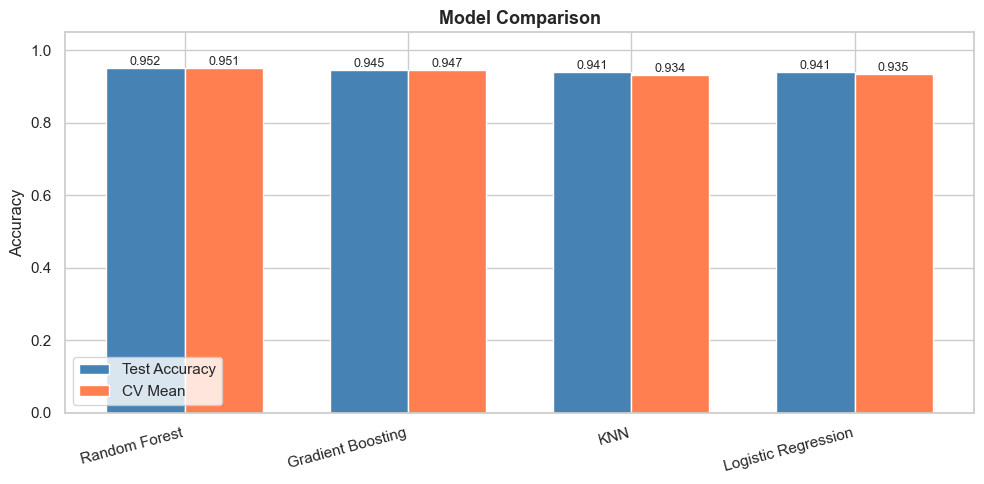

In [19]:
# comparison bar chart
names     = list(results.keys())
test_accs = [results[n]['test_acc'] for n in names]
cv_means  = [results[n]['cv_mean']  for n in names]

x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, test_accs, w, label='Test Accuracy', color='steelblue')
ax.bar(x + w/2, cv_means,  w, label='CV Mean',       color='coral')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison', fontsize=13, fontweight='bold')
ax.legend()
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.3f}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [20]:
# select best model by test accuracy
best_name   = max(results, key=lambda n: results[n]['test_acc'])
best_result = results[best_name]
best_model  = best_result['model']

print(f'Best model : {best_name}')
print(f'Test Acc   : {best_result["test_acc"]*100:.2f}%')
print(f'CV Mean    : {best_result["cv_mean"]*100:.2f}%')

Best model : Random Forest
Test Acc   : 95.15%
CV Mean    : 95.08%


## 7. Best Model Evaluation

In [21]:
print(f'Classification Report - {best_name}')
print(classification_report(y_test, best_result['y_pred'], target_names=le.classes_))

Classification Report - Random Forest
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        49
      Banana       1.00      1.00      1.00        50
      Barley       0.91      0.88      0.90        49
     Cabbage       0.91      0.83      0.87        47
 Cauliflower       0.85      0.92      0.88        48
       Chili       0.94      0.96      0.95        49
      Garlic       0.91      0.86      0.89        50
      Lentil       1.00      0.98      0.99        50
       Maize       0.98      0.94      0.96        50
       Mango       0.98      0.98      0.98        49
      Millet       0.98      1.00      0.99        50
     Mustard       0.88      0.86      0.87        50
       Onion       0.83      0.88      0.85        50
         Pea       1.00      1.00      1.00        49
      Potato       0.98      1.00      0.99        50
        Rice       1.00      1.00      1.00        50
     Soybean       0.98      1.00      0.99

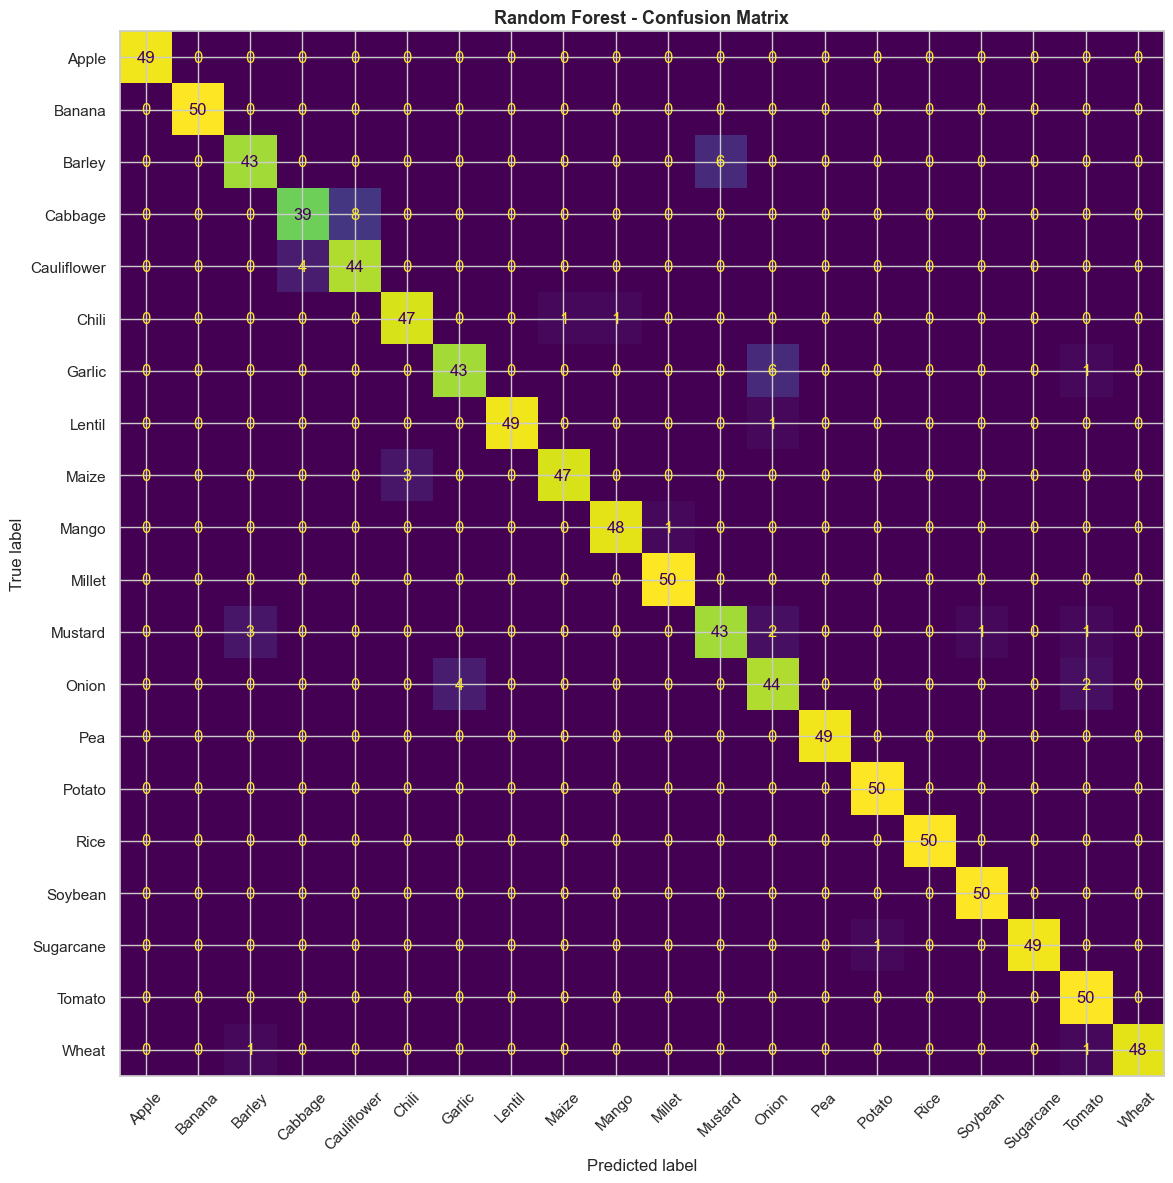

In [23]:
# confusion matrix
fig, ax = plt.subplots(figsize=(14, 12))
cm = confusion_matrix(y_test, best_result['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title(f'{best_name} - Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

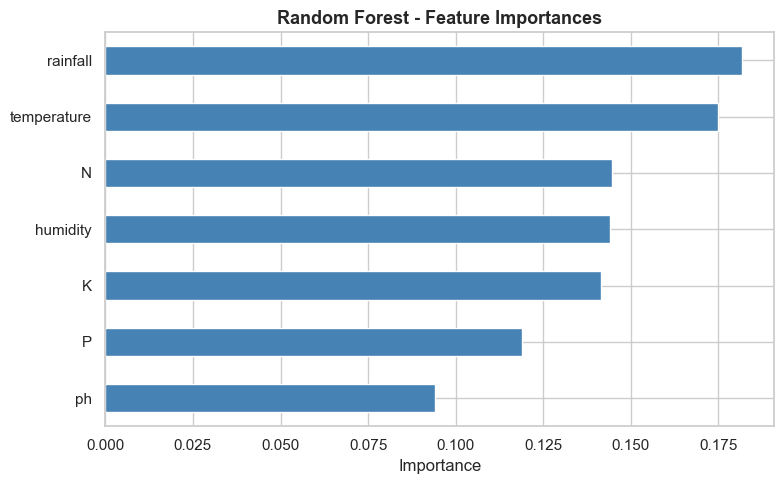

In [24]:
# feature importances (only for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{best_name} - Feature Importances', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_name} does not have feature_importances_. Skipping plot.')

## 8. Save Best Model Artifacts

In [25]:
# save scaler
with open(MODELS_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('scaler.pkl saved')

# save label encoder
with open(MODELS_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('label_encoder.pkl saved')

# save best model
with open(MODELS_DIR / 'best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f'best_model.pkl saved  ({best_name})')

# save metadata
metadata = {
    'features':      FEATURES,
    'classes':       le.classes_.tolist(),
    'best_model':    best_name,
    'test_accuracy': float(best_result['test_acc']),
    'cv_mean':       float(best_result['cv_mean']),
    'cv_std':        float(best_result['cv_std']),
    'n_train':       int(X_train.shape[0]),
    'n_test':        int(X_test.shape[0]),
    'all_results': {
        name: {
            'test_acc': float(r['test_acc']),
            'cv_mean':  float(r['cv_mean']),
            'cv_std':   float(r['cv_std']),
        }
        for name, r in results.items()
    }
}
with open(MODELS_DIR / 'metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)
print('metadata.pkl saved')

print(f'\nAll artifacts saved to: {MODELS_DIR.resolve()}')

scaler.pkl saved
label_encoder.pkl saved
best_model.pkl saved  (Random Forest)
metadata.pkl saved

All artifacts saved to: /home/prasanna/Desktop/Projects/crop_recommendation/models


In [26]:
# sanity check: reload and predict
with open(MODELS_DIR / 'best_model.pkl', 'rb') as f:
    model_loaded = pickle.load(f)
with open(MODELS_DIR / 'scaler.pkl', 'rb') as f:
    scaler_loaded = pickle.load(f)
with open(MODELS_DIR / 'label_encoder.pkl', 'rb') as f:
    le_loaded = pickle.load(f)

sample    = np.array([[90, 42, 43, 20.8, 82.0, 6.5, 202.0]])
sample_sc = scaler_loaded.transform(sample)
pred      = model_loaded.predict(sample_sc)
proba     = model_loaded.predict_proba(sample_sc)[0]
crop      = le_loaded.inverse_transform(pred)[0]

print(f'Sample prediction : {crop}')
print(f'Confidence        : {proba.max()*100:.1f}%')
print('Sanity check passed')

Sample prediction : Rice
Confidence        : 88.5%
Sanity check passed
